<a href="https://colab.research.google.com/github/AFK-Kuntal/MNIST-DigitClassification/blob/main/Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.datasets import mnist

# **Loading Dataset(only Test)**

In [3]:
(_, _), (X_test, y_test) = mnist.load_data()
X_test = X_test.astype('float32') / 255.0
X_test = np.expand_dims(X_test, axis = -1)
print(f"shape of the test set is: {X_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
shape of the test set is: (10000, 28, 28, 1)


# **Loading & Testing Model**

In [5]:
model = keras.models.load_model('digit_classifier.keras')
print("Model loaded Successfully")

Model loaded Successfully


In [6]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"test loss is {test_loss}")
print(f"test acc is {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9920 - loss: 0.0249
test loss is 0.024853913113474846
test acc is 0.9919999837875366


# **Making Prediction**

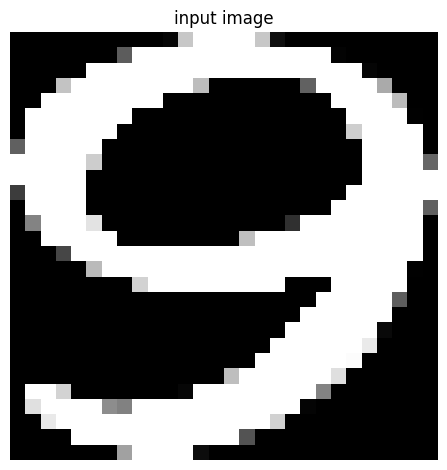

In [29]:
import cv2
img = cv2.imread(
    "images.png",
    cv2.IMREAD_GRAYSCALE
)
img = cv2.resize(img, (28, 28))
img = 255 - img #in order to get black bg and white digits
img = img.astype('float32') / 255.0
img_input = img.reshape(1, 28, 28, 1)
plt.imshow(img, cmap = 'gray')
plt.title('input image')
plt.axis('off')
plt.tight_layout()
plt.show()

In [30]:
prediction = model.predict(img_input, verbose = 0)
print(prediction)

digit = np.argmax(prediction)
print(digit)

[[6.0843147e-04 5.7006739e-03 2.5742716e-04 1.6599423e-01 8.4134713e-03
  3.5053501e-01 2.5075334e-04 7.1119247e-03 2.8820317e-03 4.5824599e-01]]
9


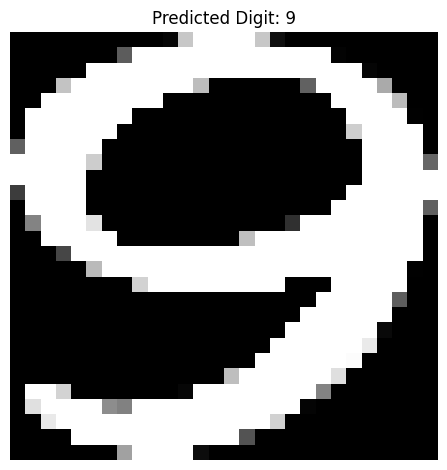

In [31]:
plt.imshow(img, cmap = 'gray')
plt.title(f"Predicted Digit: {digit}")
plt.axis('off')
plt.tight_layout()
plt.show()